In [ ]:
pip install pandas matplotlib

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
from urllib.parse import quote

In [5]:
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 下載繁體中文字型
!wget -O SourceHanSerifTW-VF.ttf https://github.com/adobe-fonts/source-han-serif/raw/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf

# 加入字型檔
fm.fontManager.addfont('SourceHanSerifTW-VF.ttf')

# 設定字型
#
mpl.rc('font', family='Source Han Serif TW VF')

--2026-05-28 05:50:19--  https://github.com/adobe-fonts/source-han-serif/raw/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/adobe-fonts/source-han-serif/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf [following]
--2026-05-28 05:50:19--  https://raw.githubusercontent.com/adobe-fonts/source-han-serif/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16851180 (16M) [application/octet-stream]
Saving to: ‘SourceHanSerifTW-VF.ttf’

SourceHanSerifTW-VF 100%[===================>]  16.07M  --.-

In [6]:
# ── 直接從政府開放資料平台下載 ──────────────────────────────────────────────
# URL = 'https://www.cbc.gov.tw/public/data/OpenData/經研處/EF15M01.csv'

# 對 URL 中的中文路徑做編碼
raw_url = 'https://www.cbc.gov.tw/public/data/OpenData/經研處/EF15M01.csv'
URL = quote(raw_url, safe=':/?=&/')   # 保留常用符號，只編中文部分
df = pd.read_csv(URL, encoding='utf-8-sig')   # 若亂碼換成 encoding='cp950'

# ── 欄位對應 ────────────────────────────────────────────────────────────────
cols = {
    'date':    '期間',
    'm1a':     '貨幣總計數 -Ｍ１Ａ-原始值',
    'm1a_yoy': '貨幣總計數 -Ｍ１Ａ-年增率',
    'm1b':     '貨幣總計數 -Ｍ１Ｂ-原始值',
    'm1b_yoy': '貨幣總計數 -Ｍ１Ｂ-年增率',
    'm2':      '貨幣總計數 -Ｍ２-原始值',
    'm2_yoy':  '貨幣總計數 -Ｍ２-年增率',
}
d = df[list(cols.values())].copy()
d.columns = list(cols.keys())

d

,date,m1a,m1a_yoy,m1b,m1b_yoy,m2,m2_yoy
0,1987M05,724916,-,1255199,-,3432119,-
1,1987M06,735215,-,1282249,-,3471977,-
2,1987M07,752435,-,1316199,-,3527812,-
3,1987M08,746253,-,1325474,-,3571849,-
4,1987M09,777150,-,1358285,-,3613090,-
...,...,...,...,...,...,...,...
462,2025M11,11917687,5.16753,28873543,4.94018,66845027,5.11267
463,2025M12,12049884,5.25334,28987198,4.84677,67081741,5.00410
464,2026M01,12277153,5.60644,29574911,5.58581,67784624,5.15973
465,2026M02,12310011,6.99875,30016162,7.11729,68453767,5.38190


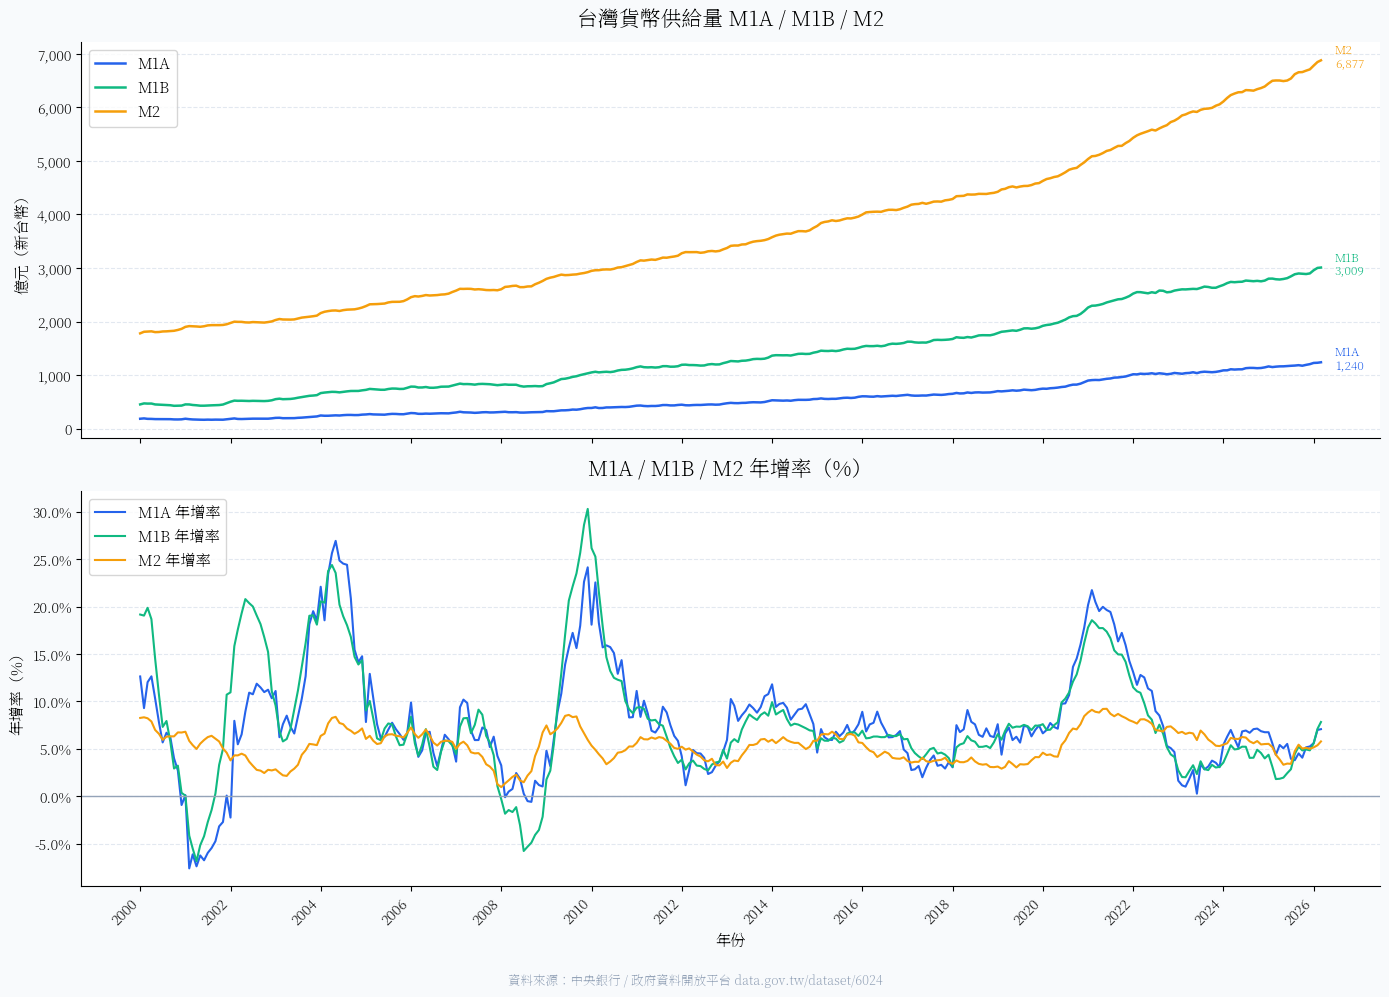

In [7]:

# ── 資料清理 ─────────────────────────────────────────────────────────────────
d['date'] = pd.to_datetime(d['date'].str.replace('M', '-'), format='%Y-%m')
for c in ['m1a_yoy', 'm1b_yoy', 'm2_yoy']:
    d[c] = pd.to_numeric(d[c], errors='coerce')   # '-' → NaN
for c in ['m1a', 'm1b', 'm2']:
    d[c] = d[c] / 1e4                              # 百萬 → 億元

d = d[d['date'] >= '2000-01-01'].reset_index(drop=True)

# ── 繪圖 ──────────────────────────────────────────────────────────────────────
COLORS = {'m1a': '#2563EB', 'm1b': '#10B981', 'm2': '#F59E0B'}
LABELS = {'m1a': 'M1A', 'm1b': 'M1B', 'm2': 'M2'}

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.patch.set_facecolor('#F8FAFC')
for ax in axes:
    ax.set_facecolor('#FFFFFF')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color='#E2E8F0', linewidth=0.8, linestyle='--')

# 上圖：原始值
ax1 = axes[0]
for key in ['m1a', 'm1b', 'm2']:
    ax1.plot(d['date'], d[key], label=LABELS[key], color=COLORS[key], linewidth=1.8)
ax1.set_title('台灣貨幣供給量 M1A / M1B / M2', fontsize=15, fontweight='bold', pad=12)
ax1.set_ylabel('億元（新台幣）', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.legend(fontsize=11, loc='upper left')
for key in ['m1a', 'm1b', 'm2']:
    last = d[['date', key]].dropna().iloc[-1]
    ax1.annotate(f"{LABELS[key]}\n{last[key]:,.0f}",
                 xy=(last['date'], last[key]),
                 xytext=(10, -5), textcoords='offset points',
                 fontsize=8.5, color=COLORS[key], fontweight='bold')

# 下圖：年增率
ax2 = axes[1]
for key in ['m1a', 'm1b', 'm2']:
    ax2.plot(d['date'], d[f'{key}_yoy'], label=f'{LABELS[key]} 年增率',
             color=COLORS[key], linewidth=1.5)
ax2.axhline(0, color='#94A3B8', linewidth=1)
ax2.set_title('M1A / M1B / M2 年增率（%）', fontsize=15, fontweight='bold', pad=12)
ax2.set_ylabel('年增率（%）', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax2.legend(fontsize=11, loc='upper left')

ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax2.set_xlabel('年份', fontsize=11)

fig.text(0.5, 0.01, '資料來源：中央銀行 / 政府資料開放平台 data.gov.tw/dataset/6024',
         ha='center', fontsize=9, color='#94A3B8')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('M1A_M1B_M2_chart.png', dpi=150, bbox_inches='tight')
plt.show()